# Mermaid Graph Rendering Reference

Developer-facing functions defined in `langchain_core.runnables.graph_mermaid`.

# `draw_mermaid`

Converts LangChain graph nodes and edges into Mermaid flowchart syntax.

```python
draw_mermaid(
    nodes: dict[str, Node], # Node identifiers mapped to graph Node objects
    edges: list[Edge], # Directed edges connecting the supplied nodes
    *,
    first_node: str | None = None, # Optional node identifier styled as the first node
    last_node: str | None = None, # Optional node identifier styled as the last node
    with_styles: bool = True, # Whether to include frontmatter and Mermaid class styles
    curve_style: CurveStyle = CurveStyle.LINEAR, # Curve style applied to graph edges
    node_styles: NodeStyles | None = None, # Optional styles for default, first, and last nodes
    wrap_label_n_words: int = 9, # Number of words placed on each edge-label line
    frontmatter_config: dict[str, Any] | None = None, # Optional Mermaid frontmatter configuration
) -> str # Return Mermaid flowchart syntax
```

## Behaviour

- Produces a top-down Mermaid graph using `graph TD`.
- Styles the specified first and last nodes differently when styles are enabled.
- Renders node metadata inside the node label.
- Groups node identifiers containing `:` into Mermaid subgraphs.
- Supports nested subgraphs.
- Raises `ValueError` when duplicate subgraph names are detected.
- Uses solid arrows for normal edges.
- Uses dotted arrows for conditional edges.
- Wraps long edge labels after the configured number of words.
- Adds Mermaid class definitions when `with_styles=True`.
- Inserts the selected curve style into Mermaid frontmatter.
- Escapes unsafe node-identifier characters automatically.

## Supporting Types

### `CurveStyle`

Controls the curve style used for Mermaid edges.

```python
CurveStyle.BASIS # Basis spline
CurveStyle.BUMP_X # Horizontal bump curve
CurveStyle.BUMP_Y # Vertical bump curve
CurveStyle.CARDINAL # Cardinal spline
CurveStyle.CATMULL_ROM # Catmull-Rom spline
CurveStyle.LINEAR # Straight line
CurveStyle.MONOTONE_X # Monotone curve along the x-axis
CurveStyle.MONOTONE_Y # Monotone curve along the y-axis
CurveStyle.NATURAL # Natural spline
CurveStyle.STEP # Step curve
CurveStyle.STEP_AFTER # Step curve changing after each point
CurveStyle.STEP_BEFORE # Step curve changing before each point
```

### `NodeStyles`

Stores Mermaid class styles for graph node categories.

```python
NodeStyles(
    default: str = "fill:#f2f0ff,line-height:1.2", # Style applied to ordinary nodes
    first: str = "fill-opacity:0", # Style applied to the first node
    last: str = "fill:#bfb6fc", # Style applied to the last node
) # Create the Mermaid node-style configuration
```

---

# `draw_mermaid_png`

Renders Mermaid syntax as PNG image bytes using either the Mermaid.INK API or a local Pyppeteer browser.

```python
draw_mermaid_png(
    mermaid_syntax: str, # Mermaid graph syntax rendered as an image
    output_file_path: str | None = None, # Optional path where the PNG image is saved
    draw_method: MermaidDrawMethod = MermaidDrawMethod.API, # Rendering method used to create the image
    background_color: str | None = "white", # Background colour name or hexadecimal colour
    padding: int = 10, # Padding around locally rendered graph content
    max_retries: int = 1, # Maximum API retry count after the initial request
    retry_delay: float = 1.0, # Base delay used for API retry backoff
    base_url: str | None = None, # Optional custom Mermaid rendering API base URL
    proxies: dict[str, str] | None = None, # Optional HTTP and HTTPS proxy settings
) -> bytes # Return rendered PNG image bytes
```

## Rendering Methods

### `MermaidDrawMethod.API`

Sends the Mermaid syntax to the Mermaid.INK API.

```python
MermaidDrawMethod.API # Render through Mermaid.INK
```

Behaviour:

- Uses `https://mermaid.ink` unless `base_url` is supplied.
- Requires the `requests` package.
- Supports proxy configuration.
- Retries server errors and request failures.
- Uses exponential backoff with random jitter.
- Saves the returned bytes when `output_file_path` is supplied.
- Raises `ValueError` when rendering fails.

### `MermaidDrawMethod.PYPPETEER`

Renders the graph locally in a headless browser.

```python
MermaidDrawMethod.PYPPETEER # Render locally with Pyppeteer
```

Behaviour:

- Requires the `pyppeteer` package.
- Loads Mermaid JavaScript from a CDN.
- Renders Mermaid syntax into SVG.
- Captures the rendered graph as PNG bytes.
- Applies the supplied background colour and padding.
- Saves the bytes when `output_file_path` is supplied.

## Errors

- Raises `ValueError` when an unsupported rendering method is supplied.
- Raises `ImportError` when the selected method's optional dependency is unavailable.
- Raises `ValueError` when the Mermaid API cannot render the graph successfully.

## Optional Dependencies

```bash
pip install requests # Install API-rendering support
pip install pyppeteer # Install local browser-rendering support
```

## Developer-Facing Top-Level Statements

```python
draw_mermaid # Convert graph data into Mermaid syntax
draw_mermaid_png # Render Mermaid syntax as PNG bytes
```

---
config:
  flowchart:
    curve: linear
---
graph TD;
	input([User Input]):::first
	process(Process Text<hr/><small><em>operation = uppercase</em></small>)
	output([Final Output]):::last
	input -- &nbsp;send text&nbsp; --> process;
	process -- &nbsp;return result&nbsp; --> output;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



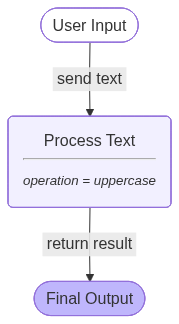

In [1]:
from IPython.display import Image, display # Import tools for displaying the PNG in Jupyter

from langchain_core.runnables.graph import CurveStyle # Import Mermaid edge-curve styles
from langchain_core.runnables.graph import Edge # Import the graph edge type
from langchain_core.runnables.graph import MermaidDrawMethod # Import Mermaid rendering methods
from langchain_core.runnables.graph import Node # Import the graph node type
from langchain_core.runnables.graph_mermaid import draw_mermaid # Import Mermaid syntax generator
from langchain_core.runnables.graph_mermaid import draw_mermaid_png # Import Mermaid PNG renderer

nodes: dict[str, Node] = { # Create graph nodes mapped by their identifiers
    "input": Node( # Create the input node
        id="input", # Set the unique node identifier
        name="User Input", # Set the displayed node label
        data=None, # Store no additional node data
        metadata=None, # Store no node metadata
    ), # Finish creating the input node
    "process": Node( # Create the processing node
        id="process", # Set the unique node identifier
        name="Process Text", # Set the displayed node label
        data=None, # Store no additional node data
        metadata={"operation": "uppercase"}, # Add metadata displayed inside the node
    ), # Finish creating the processing node
    "output": Node( # Create the output node
        id="output", # Set the unique node identifier
        name="Final Output", # Set the displayed node label
        data=None, # Store no additional node data
        metadata=None, # Store no node metadata
    ), # Finish creating the output node
} # Finish defining the nodes

edges: list[Edge] = [ # Create directed connections between nodes
    Edge( # Create the first edge
        source="input", # Set the source node
        target="process", # Set the target node
        data="send text", # Set the displayed edge label
        conditional=False, # Draw a normal solid edge
    ), # Finish creating the first edge
    Edge( # Create the second edge
        source="process", # Set the source node
        target="output", # Set the target node
        data="return result", # Set the displayed edge label
        conditional=False, # Draw a normal solid edge
    ), # Finish creating the second edge
] # Finish defining the edges

mermaid_syntax: str = draw_mermaid( # Generate Mermaid flowchart syntax
    nodes=nodes, # Supply the graph nodes
    edges=edges, # Supply the graph edges
    first_node="input", # Style the input node as the first node
    last_node="output", # Style the output node as the last node
    with_styles=True, # Include Mermaid node styles
    curve_style=CurveStyle.LINEAR, # Use straight edges
) # Finish generating Mermaid syntax

print(mermaid_syntax) # Display the generated Mermaid syntax

png_bytes: bytes = draw_mermaid_png( # Render the Mermaid graph as PNG
    mermaid_syntax=mermaid_syntax, # Supply the generated Mermaid syntax
    output_file_path="workflow.png", # Save the image in the current folder
    draw_method=MermaidDrawMethod.API, # Render through the Mermaid.INK API
    background_color="white", # Set a white image background
) # Finish rendering the PNG

display(Image(data=png_bytes)) # Display the generated PNG inside Jupyter